In [1]:
library(dplyr)
library(Matrix)
library(data.table)
library(Seurat)
library(ggplot2)
library(RColorBrewer)
cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
celltype = c("L2 IT neurons", "L2/3 IT neurons", "L3 IT neurons", "L3-6 IT neurons", "L3/4 IT neurons", 
 "L4 IT neurons", "L4/5 IT neurons", "L5 ET neurons", "L5/6 CAR3 neurons", "L5/6 NP neurons", 
 "L6 CT neurons", "L6 IT neurons", "L6b neurons", "LAMP5 neurons", "PVALB Chandelier neurons", 
 "PVALB neurons", "RELN neurons", "SST CHODL neurons", "SST neurons", "VIP neurons", 
 "Astrocytes", "Microglia", "Oligodendrocyte precursor cells", "Oligodendrocytes", 
 "Vascular cells")
best_color = c("#00e2ff", "#447AFF", "#03ff07", "#99F880", "#da32e9", 
               "#832aff", "#D9480F", "#FFB400", "#ffd43b", "#ffec99", 
               "#ffd8a8", "#ff922b", "#d9480f", "#c10265", "#bea013", 
               "#bcbe13", "#FF0000", "#ebb076", "#1b9a73", "#e06565", 
               "#ED0C7F", "#6565bc", "#b5a48d", "#A45426", "#88C6CE")
names(best_color) = celltype
mytheme <- theme(plot.title = element_text(size = 22, color = "black", hjust = 0.5),
                 axis.title = element_text(size = 20, color = "black"),
                 axis.text = element_text(size = 20, color = "black"),
                 panel.grid.minor.y = element_blank(),
                 panel.grid.minor.x = element_blank(),
                 legend.text = element_text(size = 18),
                 legend.title = element_text(size = 25),
                 axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1,margin = margin(t = 10)),
                 #legend.margin = margin(t = 0, r = 10, b = 0, l = 10)
)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Matrix’ was built under R version 4.2.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Attaching SeuratObject



In [2]:
seu = readRDS('/data/snRNA_downsample.rds')

In [4]:
table(seu$subclass.v4)


                     Astrocytes                   L2 IT neurons 
                          38246                           28583 
                L2/3 IT neurons                   L3 IT neurons 
                          45444                           32562 
                L3-6 IT neurons                 L3/4 IT neurons 
                          27046                            4052 
                  L4 IT neurons                 L4/5 IT neurons 
                          28861                           45193 
                  L5 ET neurons               L5/6 CAR3 neurons 
                            761                            7807 
                L5/6 NP neurons                   L6 CT neurons 
                           4556                            9716 
                  L6 IT neurons                     L6b neurons 
                          24340                            9043 
                  LAMP5 neurons                       Microglia 
                        

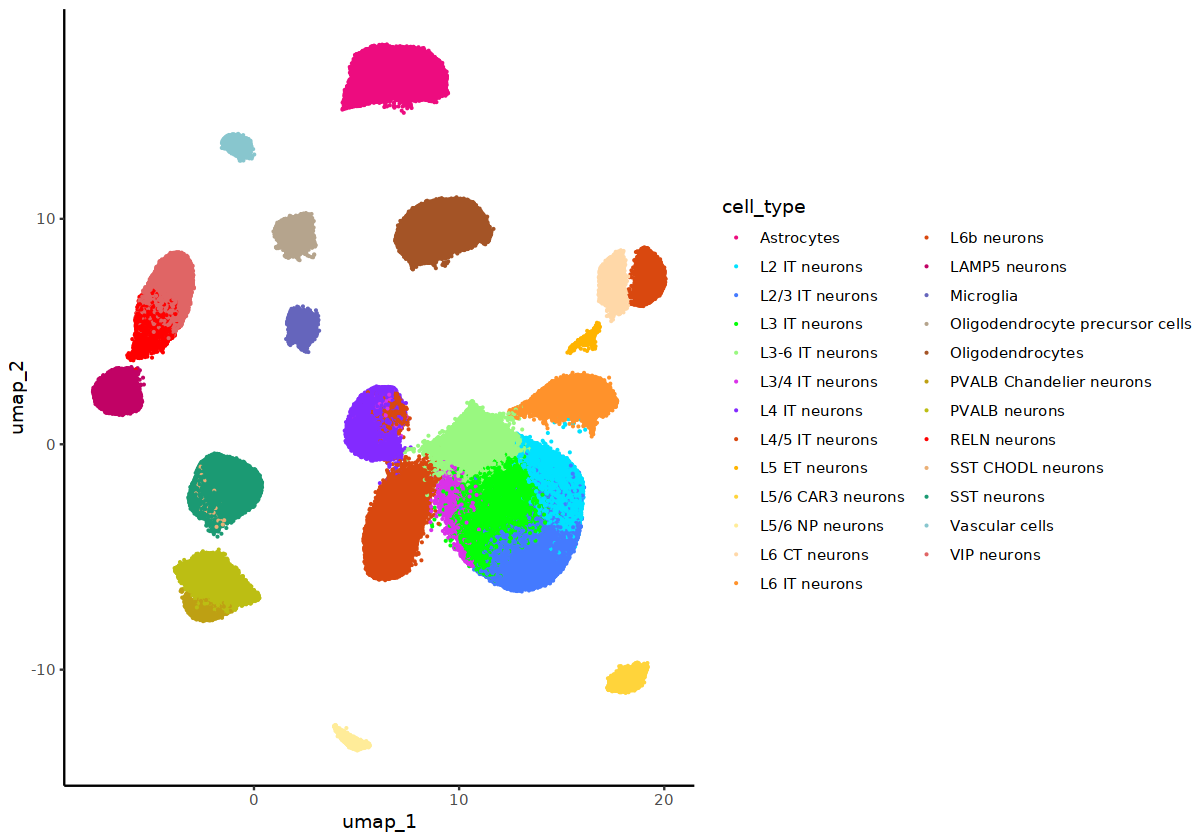

In [17]:
options(repr.plot.width=12, repr.plot.height=10)
umap = seu@reductions$umap@cell.embeddings %>% 
  as.data.frame() %>% 
  cbind(cell_type = seu@meta.data$subclass.v4)
# umap$cell_type = factor(umap$subclass.v4 ,levels = celltype)
options(repr.plot.width=10, repr.plot.height=7)
p <- ggplot(umap, aes(x = umap_1, y = umap_2, color = cell_type)) +
  geom_point(size = 0.1, alpha = 1) +
  scale_color_manual(values = (best_color)) +
  theme_classic()
p 
ggsave('/data/Figure_snRNAumapplot.png',width = 12,height = 9)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


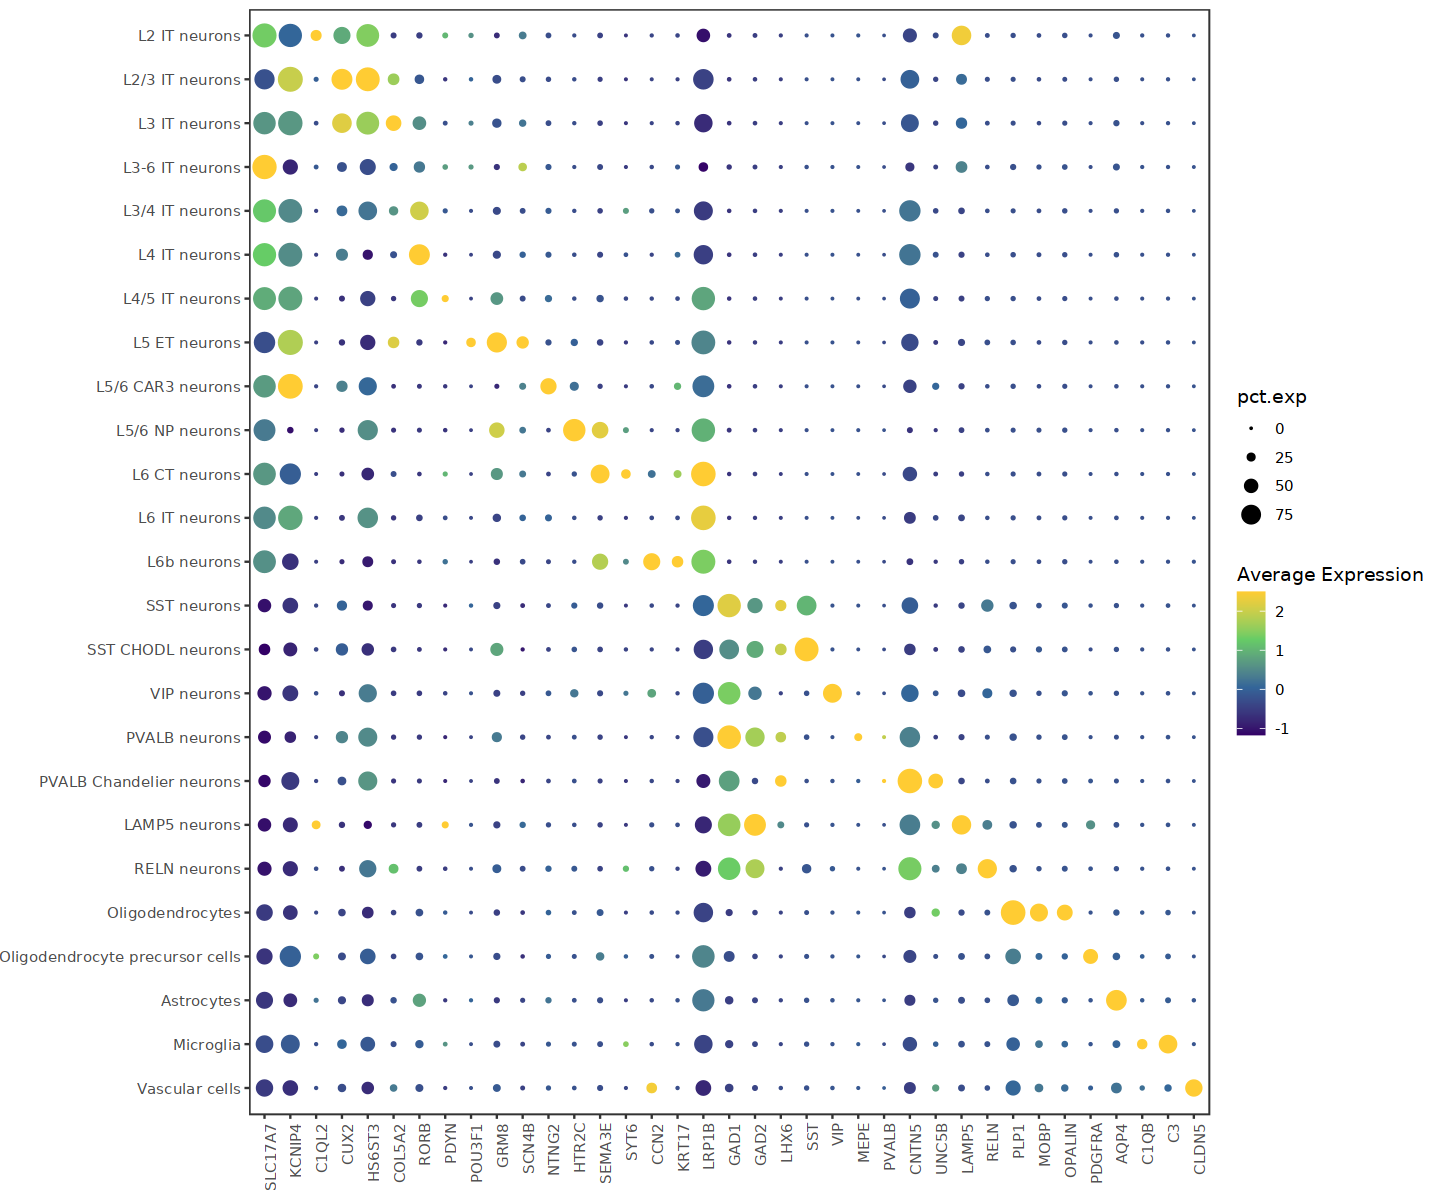

In [12]:
####dotplot
celltype.levels = c("L2 IT neurons", "L2/3 IT neurons", "L3 IT neurons", "L3-6 IT neurons", "L3/4 IT neurons", 
 "L4 IT neurons", "L4/5 IT neurons", "L5 ET neurons", "L5/6 CAR3 neurons", "L5/6 NP neurons", 
 "L6 CT neurons", "L6 IT neurons", "L6b neurons",
       'SST neurons','SST CHODL neurons','VIP neurons','PVALB neurons','PVALB Chandelier neurons','LAMP5 neurons','RELN neurons',
       'Oligodendrocytes','Oligodendrocyte precursor cells','Astrocytes','Microglia',
        'Vascular cells')
marker=unique(c("SLC17A7","KCNIP4","C1QL2","CUX2","HS6ST3" ,'COL5A2',"RORB",'PDYN','POU3F1','GRM8','SCN4B',"SCN4B" ,
         'NTNG2',"HTR2C" ,"SEMA3E" ,"SYT6" ,"CCN2","KRT17",'LRP1B',
         "GAD1","GAD2",'LHX6', "SST",'VIP','MEPE','PVALB','CNTN5','UNC5B','LAMP5','RELN',
         'PLP1',"MOBP" ,"OPALIN" ,
         "PDGFRA" ,"AQP4" ,"C1QB" ,"C3" ,"CLDN5"))
seu$subclass.v4 = factor(seu$subclass.v4,levels = rev(celltype.levels))
Idents(seu)="subclass.v4"
DefaultAssay(seu)="RNA"
p = DotPlot(seu, features = marker)+#coord_flip()+
theme_bw()+
theme(panel.grid = element_blank(), axis.text.x=element_text(hjust = 1,angle = 90))+
labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3))+
scale_color_gradientn(values = seq(0,1,0.2),colours = c('#330066','#336699','#66CC66','#FFCC33'))
options(repr.plot.width=12, repr.plot.height=10) 
p

In [13]:
ggsave('/data/Figure_snRNAdotpplot.pdf',width = 11,height = 8)